In [1]:
import numpy as np
import pandas as pd

## Import the Data



In [2]:
df = pd.read_csv('/content/Titanic-Dataset.csv')

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## data exploration

In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.shape

(891, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [8]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

## Data Cleaning

In [9]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [10]:
import seaborn as sns

<Axes: ylabel='Age'>

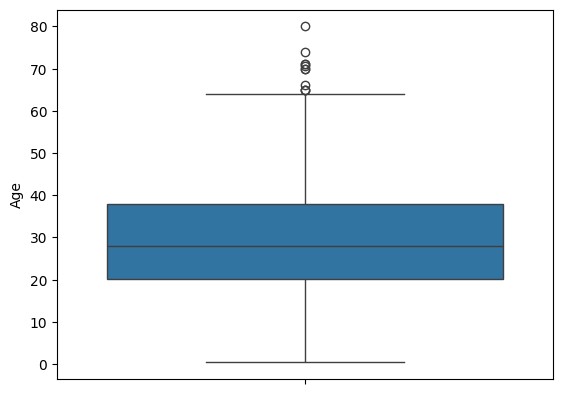

In [11]:
sns.boxplot(df['Age'])

In [12]:
df['Age'].fillna(df['Age'].mean(),inplace = True)

/tmp/ipykernel_5415/1652017284.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace = True)


In [13]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [14]:
df.dropna(thresh = len(df)*0.5 , axis = 1 , inplace = True)

In [15]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [16]:
df['Embarked'].fillna(df['Embarked'].mode()[0],inplace = True)

/tmp/ipykernel_5415/1718695086.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0],inplace = True)


In [17]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


## Duplicates checking


In [19]:
df.duplicated().sum()
# there is no duplicate values

np.int64(0)

## Outliers Checking


In [20]:
import numpy as np

a = df.select_dtypes(include=np.number).columns

In [21]:
a

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

In [40]:
out = 0
for i in a:
  q1 = df[i].quantile(0.25)
  q3 = df[i].quantile(0.75)
  iqr = q3 - q1
  upper = q3 + 1.5 * iqr
  lower = q1 - 1.5 * iqr
  outliers = ((df[i] < lower) | (df[i] > upper))
  out = out+outliers.sum()
print(  out)

441


In [29]:
import seaborn as sns
import matplotlib.pyplot as plt


PassengerId


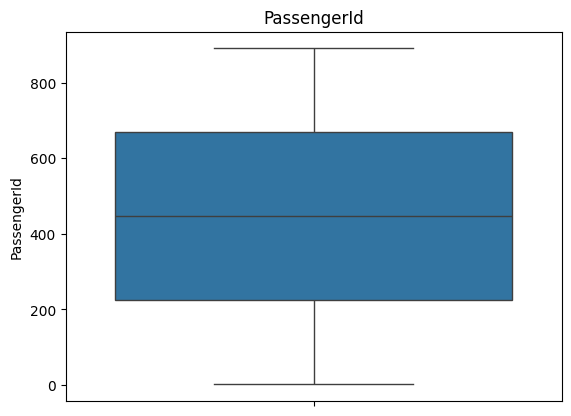

Survived


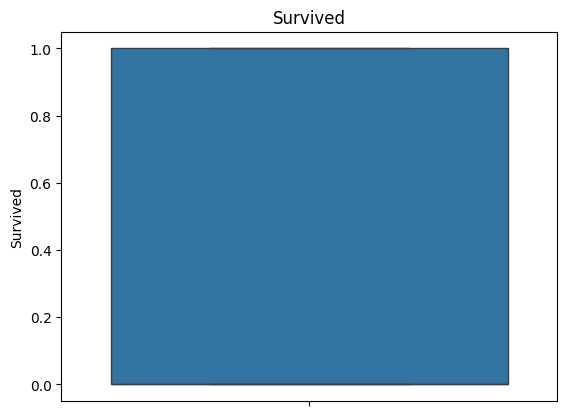

Pclass


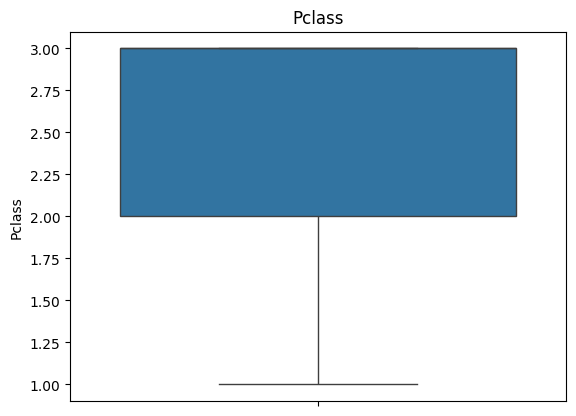

Age


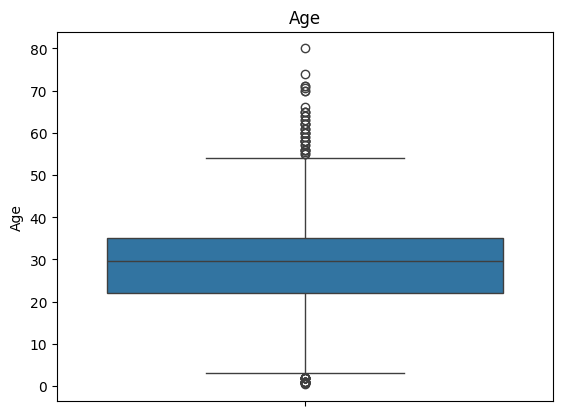

SibSp


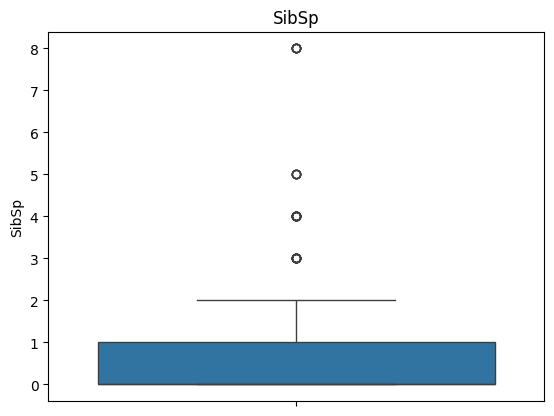

Parch


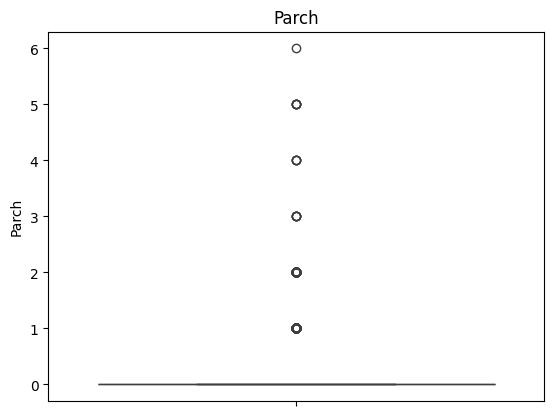

Fare


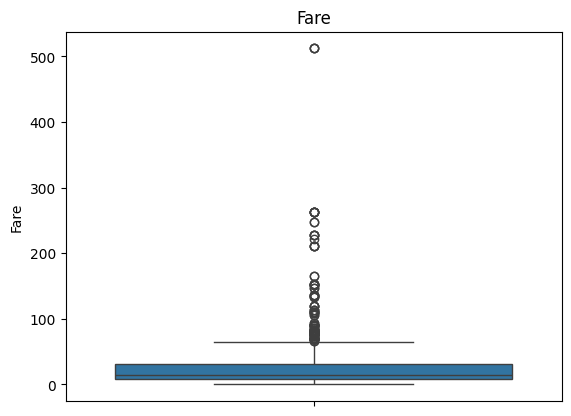

In [32]:
for i in a:
  print(i)
  sns.boxplot(df[i])
  plt.title(i)
  plt.show()

## Data analysis

In [41]:
df['PassengerId'].count()

np.int64(891)

# there are 891 passengers

In [42]:
df['Survived'].value_counts()

,count
Survived,
0,549
1,342


## Female survived more in the incident

In [43]:
b=pd.DataFrame(df.groupby("Pclass")["Survived"].mean()*100)
b

,Survived
Pclass,
1,62.962963
2,47.282609
3,24.236253


## Passengers from the class 1 survived more

In [44]:
bins=[0,18,36,72]
labels=["child","adult","old"]
df["Agegroup"]=pd.cut(df["Age"],bins=bins,labels=labels)

In [ ]:
bins=[0,18,36,72]
labels=["child","adult","old"]
df["Agegroup"]=pd.cut(df["Age"],bins=bins,labels=labels)

In [45]:
c=pd.DataFrame(df.groupby("Agegroup")["Survived"].mean()*100)
c

/tmp/ipykernel_5415/2098492148.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  c=pd.DataFrame(df.groupby("Agegroup")["Survived"].mean()*100)


,Survived
Agegroup,
child,50.359712
adult,35.906643
old,36.787565


### Child survived more in the incident

In [46]:
df.sort_values(by="Fare",ascending=False).head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Agegroup
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,C,adult
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,C,adult
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,C,adult
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,S,adult
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,S,old


### The customers who are paying the more, surviving the more


In [47]:
df["FAmilyMembers"]=df["SibSp"]+df["Parch"]

In [48]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Agegroup,FAmilyMembers
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,adult,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,old,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,adult,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,adult,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,adult,0


In [49]:
df["FAmilyMembers"].sum()

np.int64(806)

### 90% of the passengers were the family members

In [51]:
df["Name"].str.contains("Mr.").sum()

np.int64(647)

### 70%-80% of the passengers were married

# DATA VISULALISATION

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

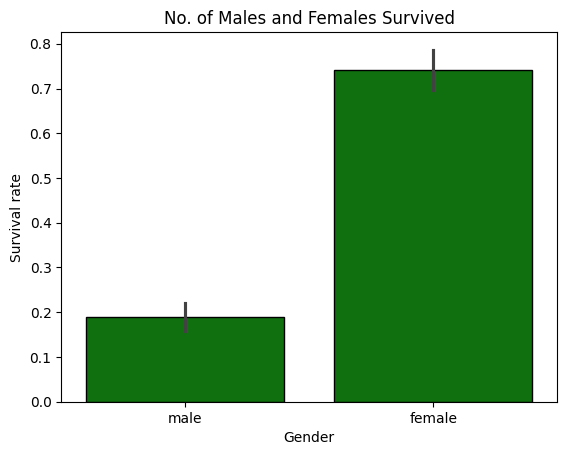

In [54]:
sns.barplot(x="Sex",y="Survived",data=df,color="green",edgecolor="black")
plt.title("No. of Males and Females Survived")
plt.xlabel("Gender")
plt.ylabel("Survival rate")
plt.show()

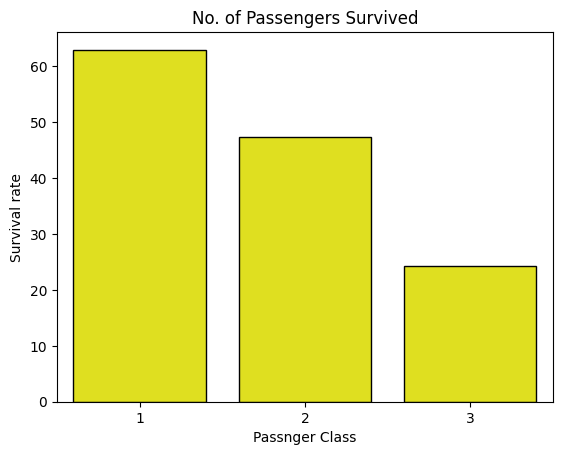

In [55]:
sns.barplot(x="Pclass",y="Survived",data=b,color="yellow",edgecolor="black")
plt.title("No. of Passengers Survived")
plt.xlabel("Passnger Class")
plt.ylabel("Survival rate")
plt.show()

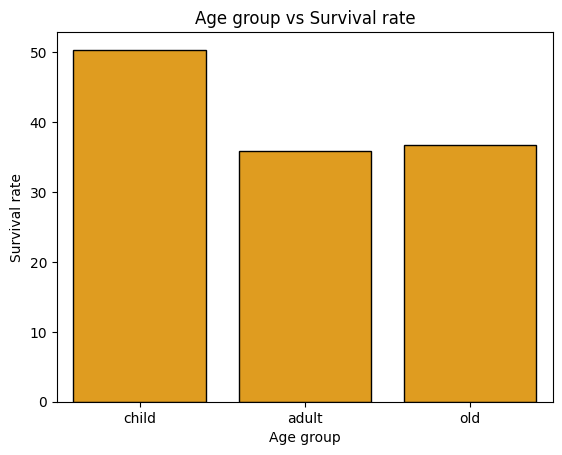

In [56]:
sns.barplot(x="Agegroup",y="Survived",data=c,color="orange",edgecolor="black")
plt.title("Age group vs Survival rate")
plt.xlabel("Age group")
plt.ylabel("Survival rate")
plt.show()

# DASHBOARD

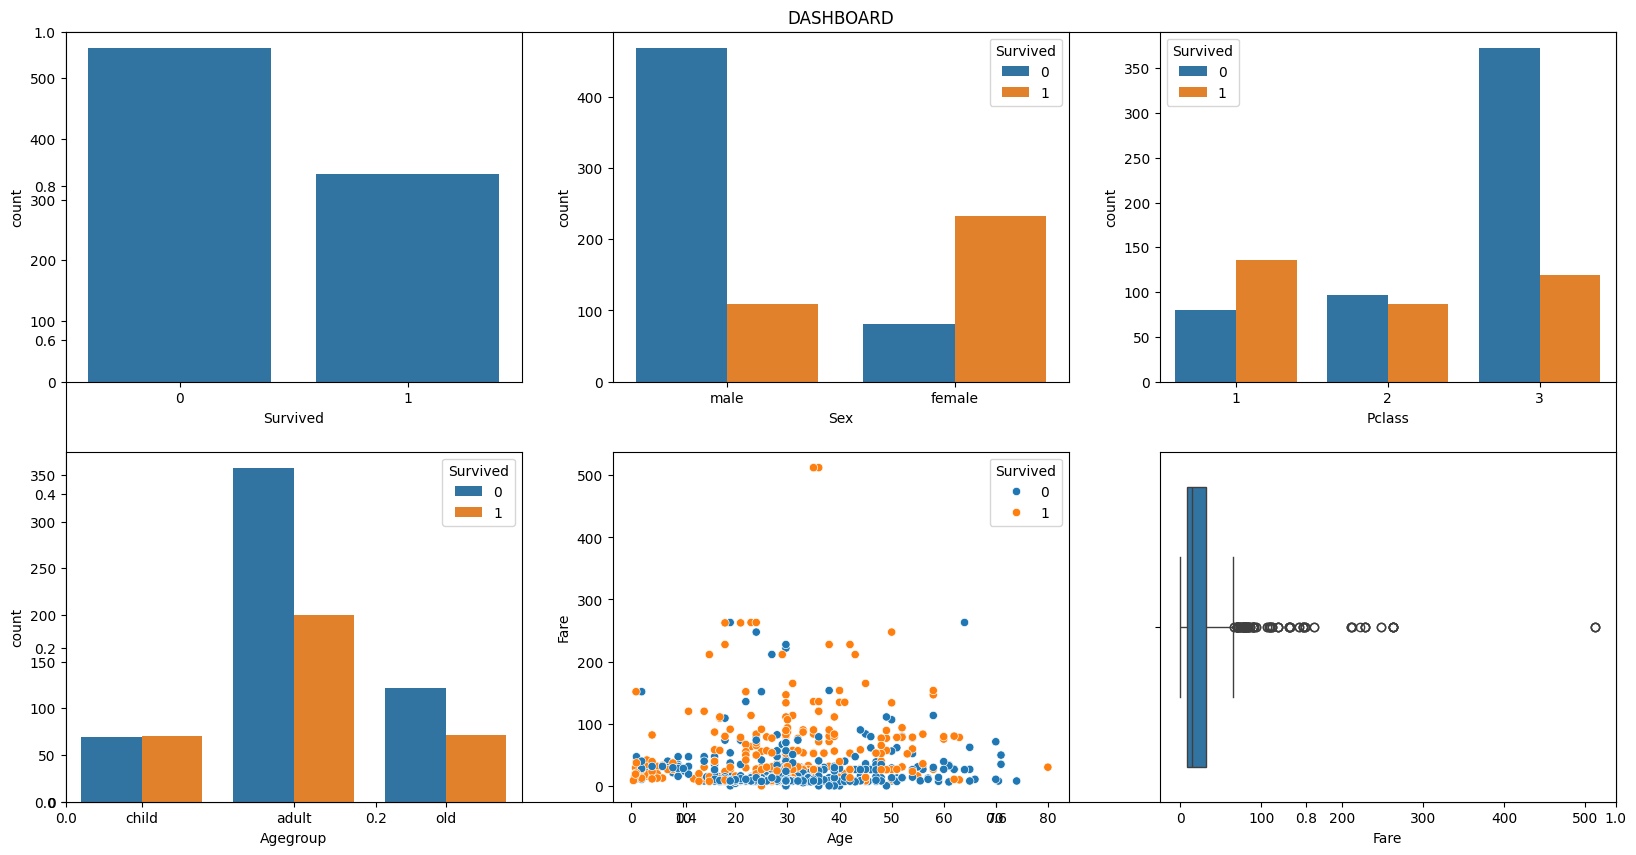

In [57]:
plt.figure(figsize=(20,10))
plt.title("DASHBOARD")
plt.subplot(2,3,1)
sns.countplot(x="Survived",data=df)
plt.subplot(2,3,2)
sns.countplot(x="Sex",hue="Survived",data=df)
plt.subplot(2,3,3)
sns.countplot(x="Pclass",hue="Survived",data=df)
plt.subplot(2,3,4)
sns.countplot(x="Agegroup",hue="Survived",data=df)
plt.subplot(2,3,5)
sns.scatterplot(x="Age",y="Fare",hue="Survived",data=df)
plt.subplot(2,3,6)
sns.boxplot(x="Fare",data=df)
plt.show()

# DATA STORY TELLING

### 1. Most people have died in the incident.
### 2. Mostof the males died in the incident.
### 3. MOst of the people are survived from passenger class 1
### 4. Survival rate of the children are more as compared to adults and olds.
### 5. People who are paying more, surviving the more.
### 6. Around 20 people are paying more than the average people.